In [5]:
# Standard libraries
import os
import sys
from pathlib import Path
import glob
import json
import re

# =========================
# Numerical computing
# =========================
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.constants as const
from scipy.interpolate import interp1d, RegularGridInterpolator
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter

# =========================
# Plotting
# =========================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

# =========================
# HDF5 / MATLAB / Lumerical data
# =========================
import h5py

# =========================
# Notebook display helpers
# =========================
from IPython.display import display, Markdown

In [10]:
# Plot style
# =========================
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "lines.linewidth": 2,
    "image.cmap": "jet",
})

# Useful constants
c0 = const.c
eps0 = const.epsilon_0
mu0 = const.mu_0

# Calculate the effective NA of the Gen 1 system #
## First, we need to know the mode size when light leaves the planar lens. ##

In [11]:
def read_lumerical_txt(filepath):
    """
    Read a Lumerical txt export with coordinate blocks and one 2D data matrix.

    Expected structure:
        header
        y(m)(Ny,1)
        Ny values
        z(m)(Nz,1)
        Nz values
        monitor:... (Ny,Nz)
        Ny rows of Nz values

    Returns
    -------
    y : np.ndarray
        y coordinates in meters
    z : np.ndarray
        z coordinates in meters
    data : np.ndarray
        2D field/data array with shape (len(y), len(z))
    metadata : dict
        Header information
    """

    filepath = Path(filepath)

    with open(filepath, "r") as f:
        lines = f.readlines()

    metadata = {
        "filepath": str(filepath),
        "header": lines[0].strip()
    }

    # Find coordinate and data headers
    y_header_idx = None
    z_header_idx = None
    data_header_idx = None

    for i, line in enumerate(lines):
        if line.startswith("y("):
            y_header_idx = i
        elif line.startswith("z("):
            z_header_idx = i
        elif line.startswith("monitor:") and "(" in line and "," in line:
            data_header_idx = i

    if y_header_idx is None or z_header_idx is None or data_header_idx is None:
        raise ValueError("Could not find y, z, or data header in the file.")

    # Extract dimensions from headers, e.g. y(m)(2691,1)
    def extract_shape(header):
        match = re.search(r"\((\d+),\s*(\d+)\)", header)
        if match is None:
            raise ValueError(f"Could not extract shape from header: {header}")
        return int(match.group(1)), int(match.group(2))

    Ny, _ = extract_shape(lines[y_header_idx])
    Nz, _ = extract_shape(lines[z_header_idx])
    Ny_data, Nz_data = extract_shape(lines[data_header_idx])

    # Read y and z
    y = np.array([
        float(lines[i].strip())
        for i in range(y_header_idx + 1, y_header_idx + 1 + Ny)
    ])

    z = np.array([
        float(lines[i].strip())
        for i in range(z_header_idx + 1, z_header_idx + 1 + Nz)
    ])

    # Read 2D data matrix
    data_lines = lines[data_header_idx + 1 : data_header_idx + 1 + Ny_data]

    data = np.array([
        [float(x) for x in line.split()]
        for line in data_lines
    ])

    if data.shape != (Ny_data, Nz_data):
        raise ValueError(
            f"Data shape mismatch. Expected {(Ny_data, Nz_data)}, got {data.shape}"
        )

    metadata["Ny"] = Ny
    metadata["Nz"] = Nz
    metadata["data_header"] = lines[data_header_idx].strip()

    return y, z, data, metadata

In [12]:
file_path = "/Users/yiyangzhi/Downloads/spherical_planar_lens_output.txt"

y, z, E, meta = read_lumerical_txt(file_path)

print("y shape:", y.shape)
print("z shape:", z.shape)
print("E shape:", E.shape)
print(meta)

y shape: (2691,)
z shape: (167,)
E shape: (2691, 167)
{'filepath': '/Users/yiyangzhi/Downloads/spherical_planar_lens_output.txt', 'header': 'monitor:E: Re(E) vs position, x=0.000238979(m), lambda=7.29e-07(m)', 'Ny': 2691, 'Nz': 167, 'data_header': 'monitor:E: Re(E) vs position, x=0.000238979(m), lambda=7.29e-07(m) (2691,167)'}


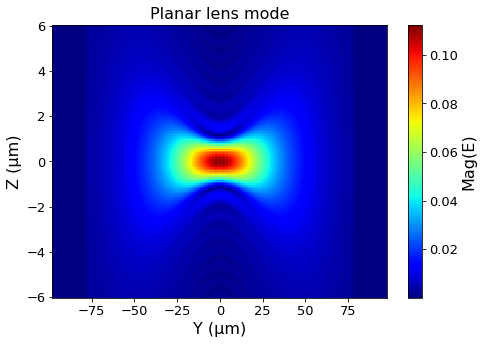

In [16]:
Y_um = y * 1e6
Z_um = z * 1e6

E_magnitude = np.transpose(np.abs(E))

plt.figure(figsize=(7, 5))
plt.pcolormesh(Y_um, Z_um, E_magnitude, shading="auto")
plt.xlabel("Y (µm)")
plt.ylabel("Z (µm)")
plt.title("Planar lens mode")
plt.colorbar(label="Mag(E)")
plt.tight_layout()
plt.show()

## Once we have the field, we can do a line-cut at z = 0 µm and fit to get the mode size. ##

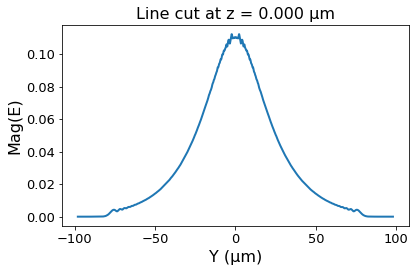

In [18]:
z0_idx = np.argmin(np.abs(z))
E_cut = E_magnitude[z0_idx, :]

plt.figure(figsize=(6, 4))
plt.plot(Y_um, E_cut)
plt.xlabel("Y (µm)")
plt.ylabel("Mag(E)")
plt.title(f"Line cut at z = {z[z0_idx]*1e6:.3f} µm")
plt.tight_layout()
plt.show()

In [20]:
def gaussian_field(y, A, y0, w, C):
    """
    Gaussian field magnitude:
        E(y) = A * exp(-(y-y0)^2 / w^2) + C

    w is the 1/e field radius.
    """
    return A * np.exp(-((y - y0) ** 2) / (w ** 2)) + C


A0 = np.max(E_cut) - np.min(E_cut)
y0_0 = Y_um[np.argmax(E_cut)]
w0 = 20  # initial guess in um; adjust if needed
C0 = np.min(E_cut)

p0 = [A0, y0_0, w0, C0]

# Bounds: A positive, waist positive
bounds = (
    [0, np.min(Y_um), 0, -np.inf],
    [np.inf, np.max(Y_um), np.inf, np.inf]
)

popt, pcov = curve_fit(
    gaussian_field,
    Y_um,
    E_cut,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

A_fit, y0_fit, w_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"Fitted center y0 = {y0_fit:.3f} ± {perr[1]:.3f} µm")
print(f"Fitted waist w = {w_fit:.3f} ± {perr[2]:.3f} µm")
print(f"z position = {z[z0_idx]*1e6:.3f} µm")

Fitted center y0 = -0.000 ± 0.042 µm
Fitted waist w = 29.934 ± 0.072 µm
z position = 0.000 µm


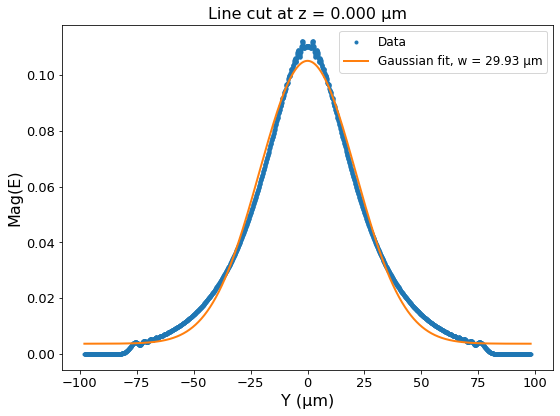

In [23]:
y_dense = np.linspace(np.min(Y_um), np.max(Y_um), 2000)
E_fit = gaussian_field(y_dense, *popt)

plt.figure(figsize=(8, 6))
plt.plot(Y_um, E_cut, ".", label="Data")
plt.plot(y_dense, E_fit, "-", label=f"Gaussian fit, w = {w_fit:.2f} µm")
plt.xlabel("Y (µm)")
plt.ylabel("Mag(E)")
plt.title(f"Line cut at z = {z[z0_idx]*1e6:.3f} µm")
plt.legend()
plt.tight_layout()
plt.show()